# Assignment 2 – Stage 2: Hidden Test Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import sentiment_lib as sl

hidden = pd.read_csv("hidden_test.csv")
print("hidden test:", hidden.shape)
print(dict(hidden["label"].value_counts()))

hidden test: (600, 5)
{0: np.int64(300), 1: np.int64(300)}


In [2]:
# Load the frozen Stage 1 checkpoint and featurize the hidden test set
members, cfg = sl.load_checkpoint("model_checkpoint")
print(cfg)

kv = sl.load_glove()
POS, NEG = sl.load_lexicon()
X_hidden = sl.featurize(hidden["text"].tolist(), kv, POS, NEG)
pred = sl.predict(members, X_hidden)

{'model': 'linear-ensemble', 'n_members': 5, 'n_features': 306, 'embedding': 'glove-wiki-gigaword-300 (mean pooled)', 'lexicon': 'nltk opinion_lexicon (Hu & Liu)', 'seeds': [0, 1, 2, 3, 4]}


## Hidden test accuracy and confusion matrix

hidden test accuracy          : 0.7633
hidden test balanced accuracy : 0.7633


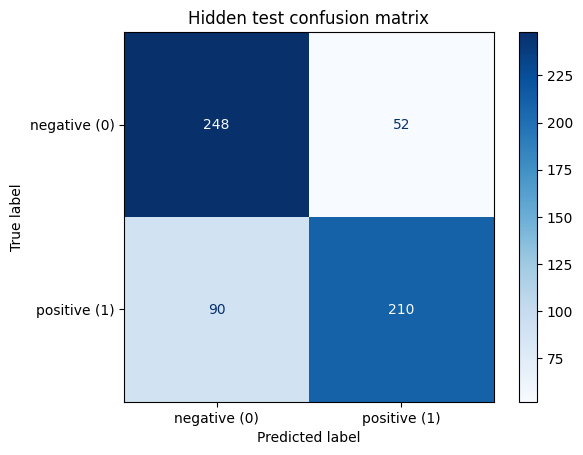

[[248  52]
 [ 90 210]]


In [3]:
y_hidden = hidden["label"].values
acc = accuracy_score(y_hidden, pred)
bal = balanced_accuracy_score(y_hidden, pred)
print(f"hidden test accuracy          : {acc:.4f}")
print(f"hidden test balanced accuracy : {bal:.4f}")

cm = confusion_matrix(y_hidden, pred)
ConfusionMatrixDisplay(cm, display_labels=["negative (0)", "positive (1)"]).plot(cmap="Blues", values_format="d")
plt.title("Hidden test confusion matrix")
plt.show()
print(cm)

In [4]:
pd.DataFrame({"id": hidden["id"], "predicted_label": pred}).to_csv("hidden_test_predictions.csv", index=False)
print("saved hidden_test_predictions.csv")

saved hidden_test_predictions.csv


## Public vs. hidden test comparison

| Test set | Size | Accuracy | Balanced accuracy |
|---|---|---|---|
| Public test (Stage 1) | 400 | 0.7575 | 0.7575 |
| Hidden test (Stage 2) | 600 | 0.7633 | 0.7633 |

Hidden test accuracy (0.7633) is almost equal to public test accuracy (0.7575) with a mere difference of only 0.6 percent. Both tests have an equal distribution and are from the same Pang & Lee corpus. Since we did not use the public test at all in training or choosing the best model, a similar performance on the hidden test implies good generalization ability.

From the confusion matrix given above, it can be seen that the model can detect more negatives (recall 0.83) than positives (recall 0.70), and hence predicts negative more often than positive. This may be because there is an imbalance of 3:1 in favor of positive in our 240 review data set.

## If we had more time and compute resources

* **Fine-tune a small pretrained Transformer** with small learning rate, layer freezing, and strong regularization. Contextual embedding is expected to outperform frozen GloVe averaging even on 240 labels.
* **Better encoding:** apply SIF or weighted pooling, or use sentence-level encoding with sentence attention because reviews are long, contain a lot of plot and opinion, and average pooling degrades the opinionated sentences.
* **Semi-supervised learning:** via pseudo-labeling or consistency training of the model using unlabeled movie reviews to address the problem of a small number of labeled samples.
* **Data augmentation**  embedding space mixup of training examples and adjust the decision threshold using cross-validated predictions.